# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
dataset = 'Fe-Mo'  #'Cr-Co-W'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
from scipy.optimize import curve_fit

In [3]:
from ase.eos import EquationOfState, birchmurnaghan

In [4]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [5]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [6]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

<AxesSubplot:ylabel='Frequency'>

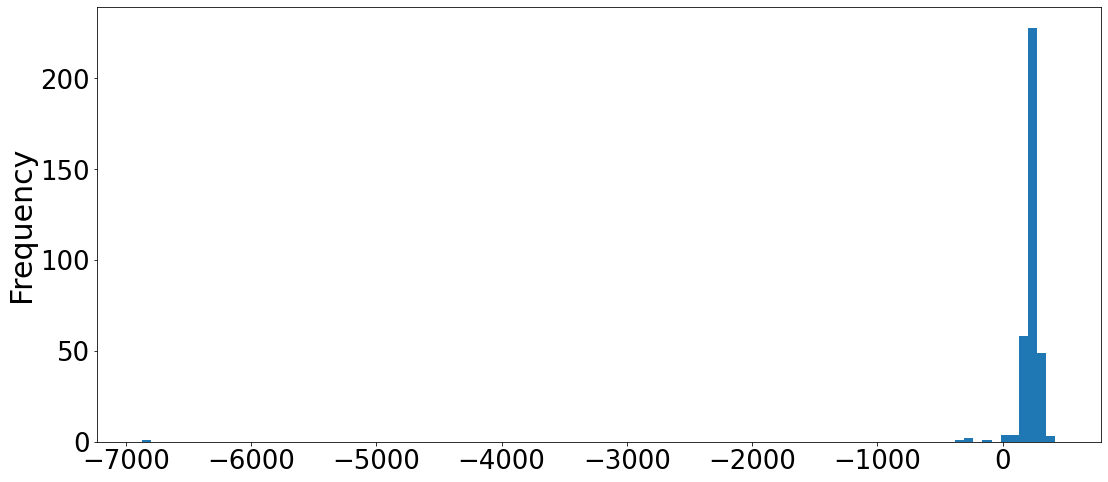

In [7]:
PBS.B0.plot.hist(bins=100)

## Investigate ev-curves

In [8]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
force = True

In [9]:
Mo_R = 'Mo_sv53.R.NM'

In [10]:
Fe_R = 'Fe_pv53.R.NM'

In [11]:
if not os.path.exists(fittedcurvesloc) or force:
    if not os.path.exists(evcurvesloc) or force:
        print('redoing')

        EV = Evcurves(Indexes = PBS.index, atoms=dataset.split(), dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

redoing


  0%|          | 0/351 [00:00<?, ?it/s]

  0%|          | 0/351 [00:00<?, ?it/s]

In [12]:
Febcc = 'Fe_pv1.bcc.FM'

([<Figure size 1296x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Fe_pv1.bcc.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

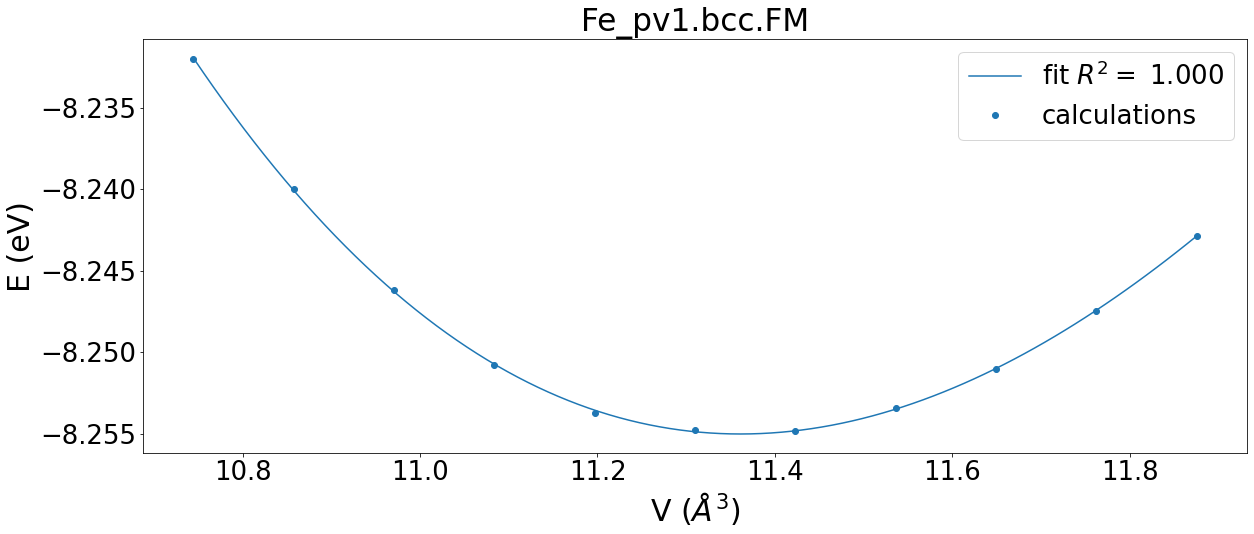

In [13]:
plot_curves(EVcurves[[Febcc]], Fits[[Febcc]], R2[[Febcc]])

In [14]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [15]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [16]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [17]:
Better_evcurves = {}

In [18]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

In [19]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [20]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [21]:
ev_fit_results_df

,E_murn,V_murn,B_murn,Bdev_murn
Fe_pv8Mo_sv22.sigma-BBABB.FM,-10.004507,14.954763,224.285410,7.275164
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-10.006896,14.130625,237.907324,4.207050
Fe_pv4Mo_sv20.C36-ABBBB.FM,-10.007837,16.270923,204.470374,4.245173
Fe_pv3Mo_sv10.mu-ABBBA.FM,-10.008565,15.378254,402.123952,-106.774345
Fe_pv5Mo_sv24.chi-AABB.FM,-10.015010,15.751001,216.183583,3.467979
...,...,...,...,...
Fe_pv4Mo_sv2.C15-A2B.FM,-9.135294,12.307425,177.924519,-2.724562
Fe_pv2Mo_sv4.C15-AB2.FM,-9.455649,15.885323,175.903078,3.940169
Fe_pv8Mo_sv16.C36-BAABB.NM,-9.611603,14.705902,232.342308,4.170758
Fe_pv4Mo_sv9.mu-BBBAA.FM,-9.612627,15.244665,207.420038,4.000323


In [22]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [23]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

In [24]:
fit_results_df

,E_murn,B_murn,Bdev_murn,V_murn
Fe_pv8Mo_sv22.sigma-BBABB.FM,-10.004508,224.504766,7.261221,14.954790
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-10.006897,237.945535,4.214880,14.130620
Fe_pv4Mo_sv20.C36-ABBBB.FM,-10.007837,204.312645,4.333180,16.270956
Fe_pv3Mo_sv10.mu-ABBBA.FM,-10.008460,310.905451,-36.764476,15.362713
Fe_pv5Mo_sv24.chi-AABB.FM,-10.015010,216.131543,3.519924,15.750987
...,...,...,...,...
Fe_pv4Mo_sv2.C15-A2B.FM,-9.135293,177.930697,-2.191295,12.307032
Fe_pv2Mo_sv4.C15-AB2.FM,-9.455656,175.245844,4.106883,15.886094
Fe_pv8Mo_sv16.C36-BAABB.NM,-9.611603,232.376504,4.183038,14.705893
Fe_pv4Mo_sv9.mu-BBBAA.FM,-9.612627,207.354253,4.060334,15.244654


<AxesSubplot:ylabel='Frequency'>

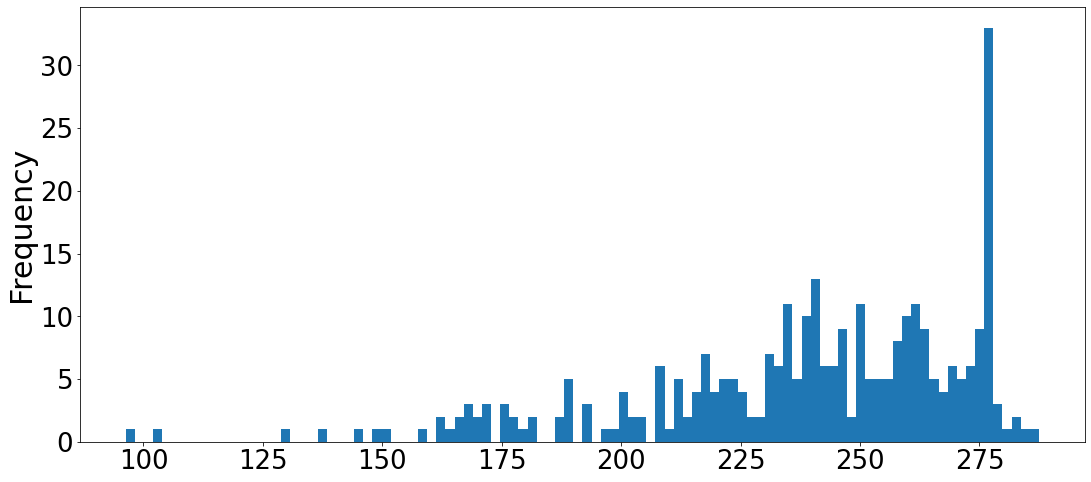

In [25]:
fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)

In [26]:
negative_B0_index = fit_results_df.query('B_murn < 0').index

In [27]:
Better_evcurves_df.IsGood[negative_B0_index]

Fe_pv13Mo_sv16.chi-ABAB.FM     False
Fe_pv10Mo_sv14.C36-ABBBA.FM    False
Name: IsGood, dtype: bool

# Differences between fits and available data

In [28]:
diff_fit_to_dataset = PBS.B0 - fit_results_df.B_murn

In [29]:
import seaborn as sns

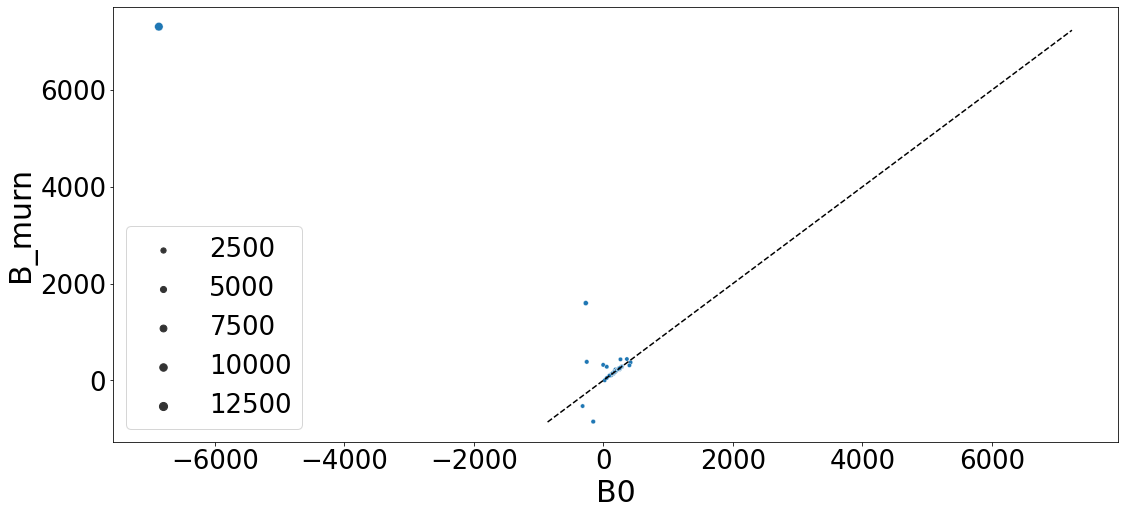

In [30]:
ax = sns.scatterplot(x=PBS.B0, y=fit_results_df.B_murn, size = diff_fit_to_dataset.abs())
themin = fit_results_df.B_murn.min()
themax = fit_results_df.B_murn.max()
plt.plot([themin*1.01, themax*0.99],[themin*1.01, themax*0.99] , '--k')

In [31]:
large_diffs = (diff_fit_to_dataset / PBS.B0).abs()>0.01

In [32]:
pd.concat ( [PBS[large_diffs].B0, fit_results_df.B_murn[large_diffs]], axis=  1 )

,B0,B_murn
Fe_pv3Mo_sv10.mu-ABBBA.FM,402.123952,310.905451
Fe_pv1.fcc.FM,-2.685409,320.005888
Fe_pv4.fcc-cubic.FM,-257.002805,382.539340
Fe_pv8.A15.FM,91.497861,96.307020
Fe_pv28Mo_sv1.chi-BAAA.FM,20.484025,0.797575
Fe_pv1.bcc.FM,170.727430,189.193754
Fe_pv11Mo_sv2.mu-AAABA.FM,-271.520165,1597.234839
Fe_pv11Mo_sv2.mu-AABAA.FM,-6867.530562,7312.123299
Fe_pv18Mo_sv6.C36-AAABA.FM,52.655676,280.513972
Fe_pv25Mo_sv4.chi-ABAA.FM,134.837320,137.463235


In [33]:
pd.concat ( [PBS.V0, PBS.E0, fit_results_df.E_murn], axis=  1 )[large_diffs & Better_evcurves_df.IsGood].shape

(5, 3)

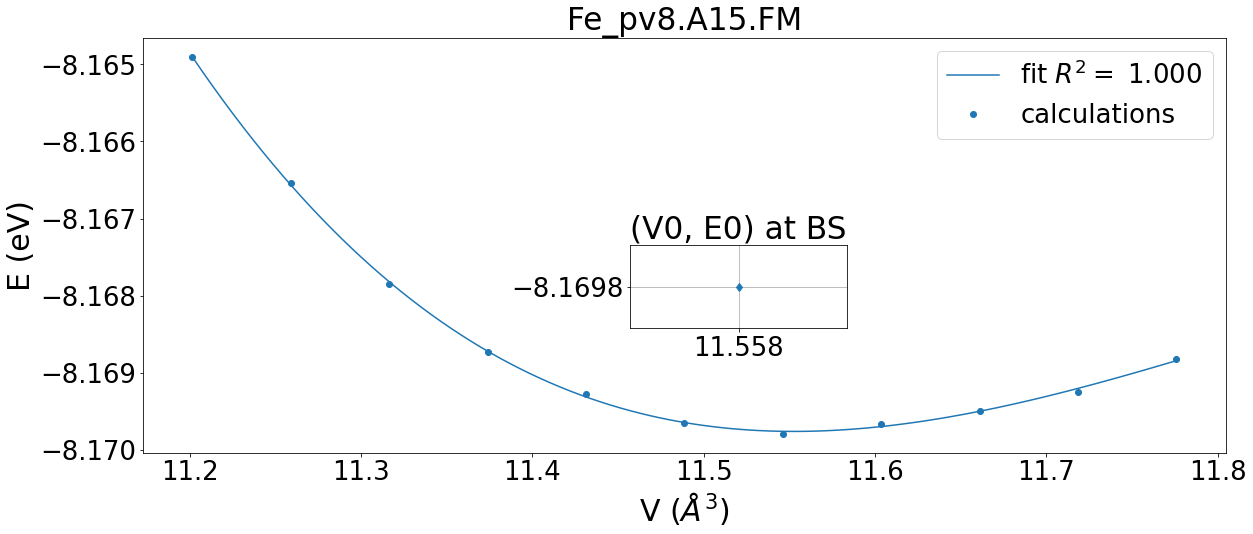

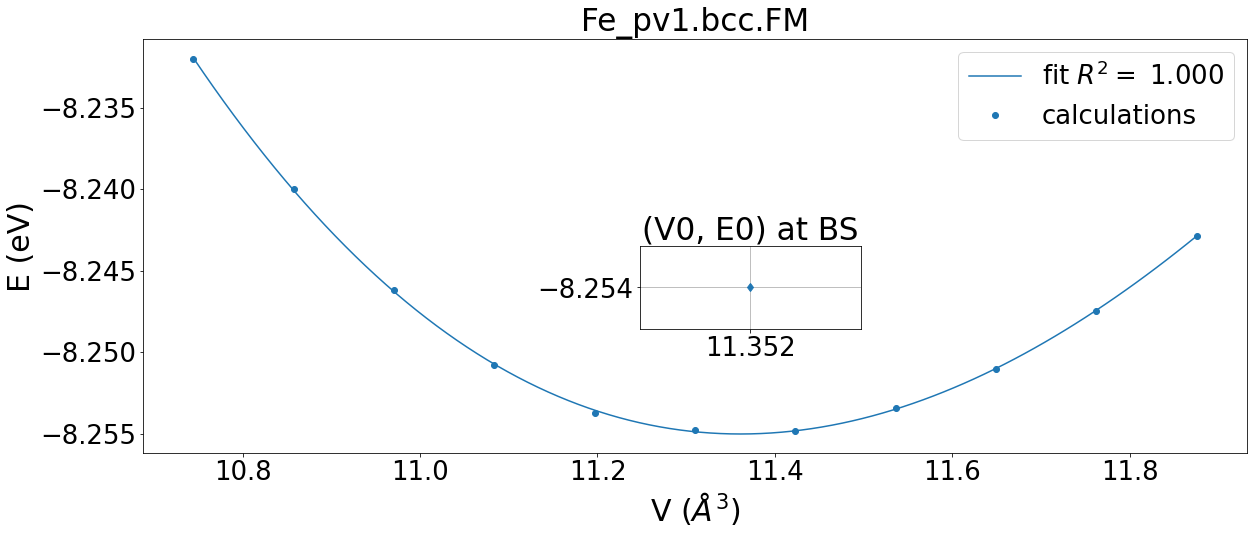

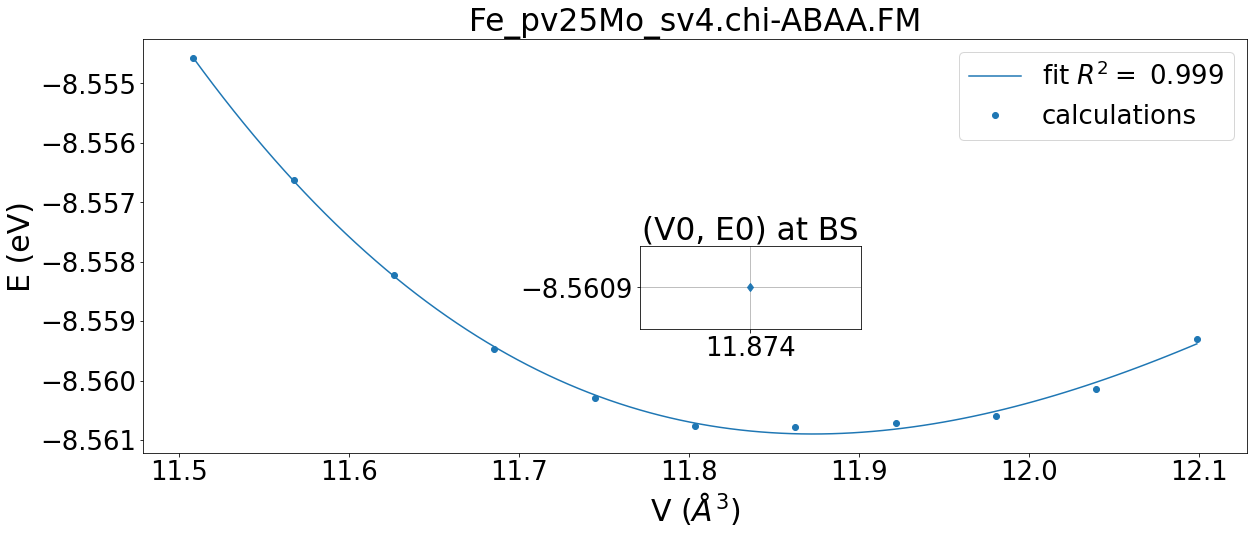

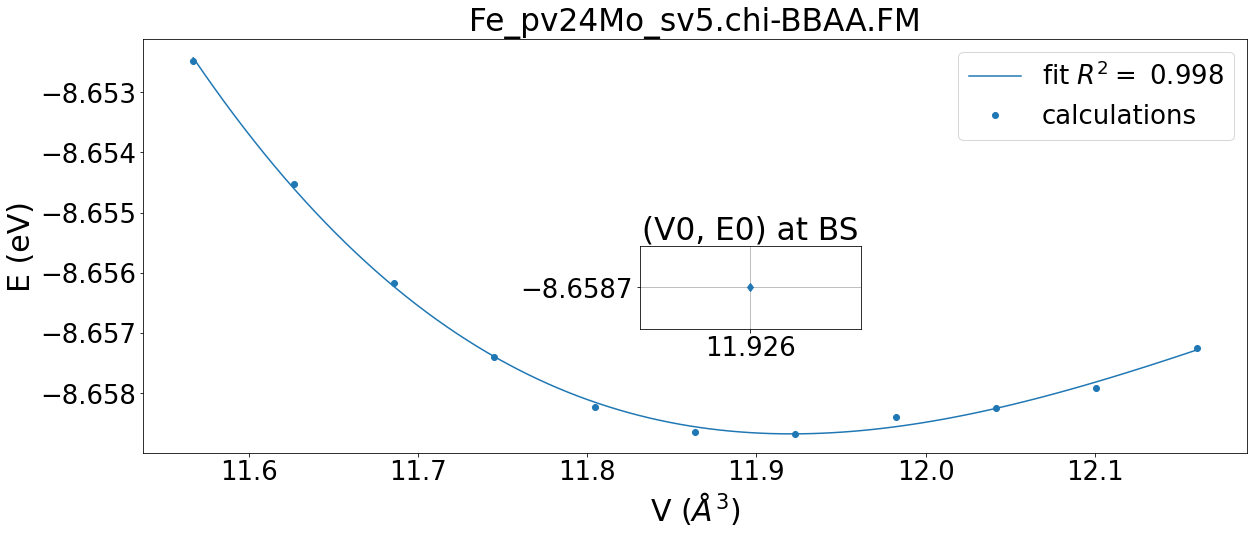

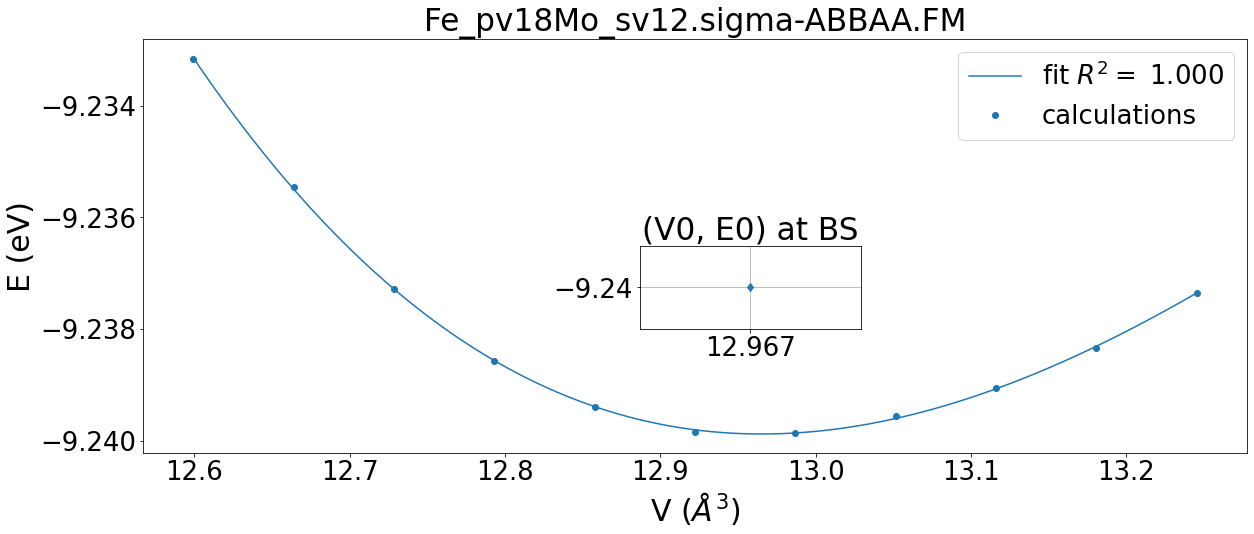

In [34]:
figs, axs = plot_curves(EVcurves[large_diffs & Better_evcurves_df.IsGood], Fits[large_diffs & Better_evcurves_df.IsGood], R2[large_diffs & Better_evcurves_df.IsGood])
for fig, ax  in zip(figs, axs):
    index = ax.title.get_text()
    V0, E0 = PBS[['V0','E0']].loc[index].values
    axins = ax.inset_axes([0.45, 0.3, 0.2, 0.2])
    axins.plot([V0], [E0], 'd')
    axins.set_title('(V0, E0) at BS')
    axins.set_xticks([V0])
    axins.set_yticks([E0])
    axins.grid(visible=True)
    


# correct good samples with new E0, B0, E0

In [35]:
which_to_correct = Better_evcurves_df.IsGood & large_diffs

In [36]:
PBS.loc[Better_evcurves_df[which_to_correct].index]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.169759,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Fe_pv,,8,0,8,1.000000,0.000000,0.085084,0.085084,0.085084
Fe_pv25Mo_sv4.chi-ABAA.FM,bulk chi-ABAA.FM,11.874474 A,-8.560894,134.837320 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,25,4,29,0.862069,0.137931,0.063321,0.063321,0.063321
Fe_pv24Mo_sv5.chi-BBAA.FM,bulk chi-BBAA.FM,11.926180 A,-8.658669,124.301732 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,24,5,29,0.827586,0.172414,0.057889,0.057889,0.057889
Fe_pv18Mo_sv12.sigma-ABBAA.FM,bulk sigma-ABBAA.FM,12.966693 A,-9.239872,160.874905 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,18,12,30,0.600000,0.400000,0.086150,0.086150,0.086150
Fe_pv1.bcc.FM,bulk bcc.FM,11.352006 A,-8.254018,170.727430 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.016,0,1,...,Fe_pv,,1,0,1,1.000000,0.000000,0.000825,0.000825,0.000825


In [37]:
PBS['B0'][which_to_correct] = fit_results_df.B_murn[which_to_correct]#.shape #[ = Fits_df['B0']

In [38]:
PBS['V0'][which_to_correct] = fit_results_df.V_murn[which_to_correct]#.shape #[ = Fits_df['B0']

In [39]:
PBS['E0'][which_to_correct] = fit_results_df.E_murn[which_to_correct]#.shape #[ = Fits_df['B0']

# Test On obvious ones

In [40]:
Better_evcurves_df.loc[Mo_R].IsGood

True

In [41]:
Better_evcurves_df.loc['Fe_pv1.bcc.FM'].IsGood

True

([<Figure size 1296x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Mo_sv53.R.NM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

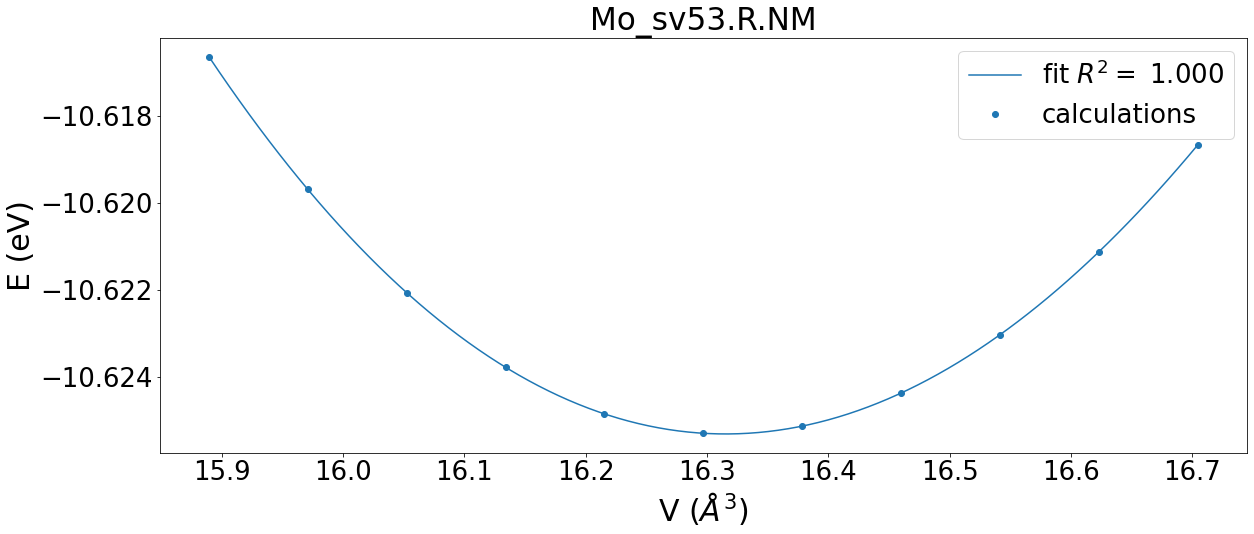

In [42]:
plot_curves(EVcurves[[Mo_R]], Fits[[Mo_R]], R2[[Mo_R]])

# Get all the good samples 

In [43]:
indexofgoodsamples = Better_evcurves_df.query('IsGood == True').index

In [44]:
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[Better_evcurves_df.index.difference(indexofgoodsamples)]

In [45]:
GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]

<AxesSubplot:ylabel='Frequency'>

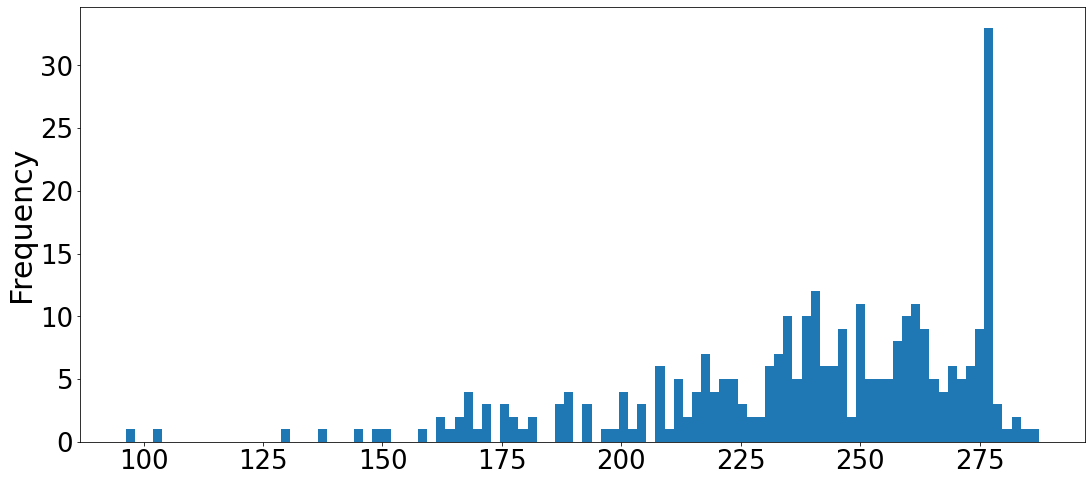

In [46]:
GoodBS.B0.plot.hist(bins=100)

<AxesSubplot:ylabel='Frequency'>

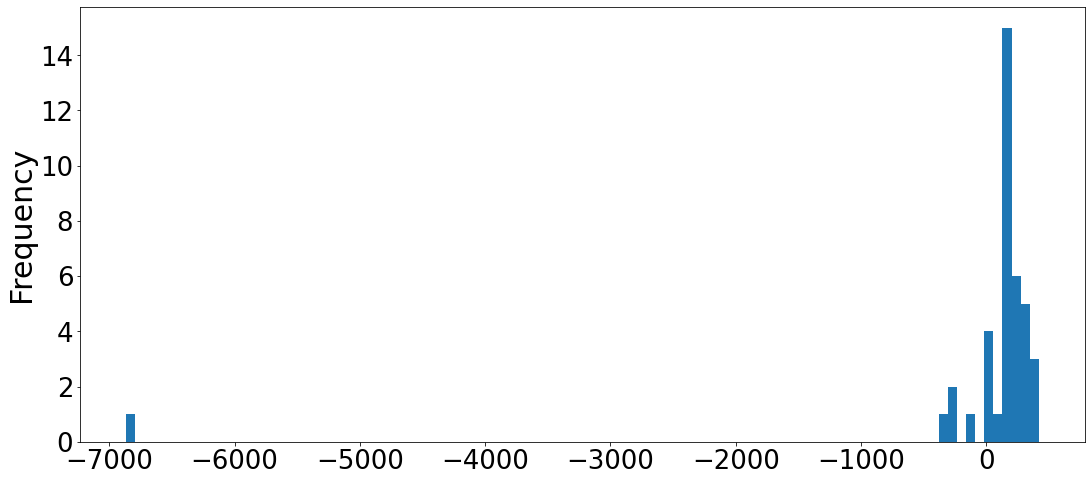

In [47]:
BadBS.B0.plot.hist(bins=100)

# Try to correct the bad fits by removing points 

In [48]:
from importlib.machinery import SourceFileLoader

In [134]:
from importlib.machinery import SourceFileLoader
find_the_good_curve_inside = SourceFileLoader('find_the_good_curve_inside','Tools/DatasetTools/EVCurvesTools.py').load_module().find_the_good_curve_inside
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')

for index, paramcurve in EVcurves[BadBS.index].items():
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        if curvedata['r2']<0.8:
            doexit=True
            break
        else:
            doexit=False
    if doexit:
        break
    

In [135]:
index

'Fe_pv13Mo_sv16.chi-ABAB.FM'

In [136]:
        r2, params_onreduced, reducedv, reducede = find_the_good_curve_inside(curvedata)

In [137]:
bestcombi = np.argmax(r2)

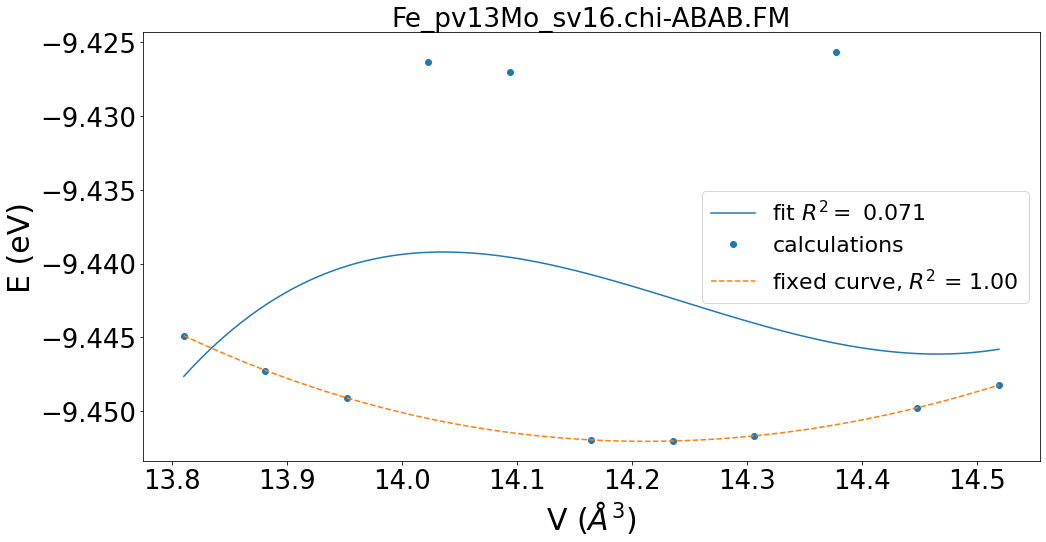

In [138]:
fig, ax = plot_curves(EVcurves[[index]], Fits[[index]],R2[[index]])
#ax[0].plot(reducedv[bestcombi], reducede[bestcombi], 'o')
xx = np.linspace(reducedv[bestcombi].min(), reducedv[bestcombi].max(), 100)
fixed_r2 = r2[bestcombi]
ax[0].plot(xx, birchmurnaghan(xx, *params_onreduced[bestcombi]), '--',label=f'fixed curve, $R^2$ = {fixed_r2:.2f} ')
ax[0].legend()

In [255]:
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : r2>0.999,
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }
        

In [255]:
from importlib.machinery import SourceFileLoader
improbe_goodness = SourceFileLoader('improbe_goodness','Tools/DatasetTools/EVCurvesTools.py').load_module().improve_goodness
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')

for index, paramcurve in EVcurves[BadBS.index].items():
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        if curvedata['r2']>0.99:
            doexit=True
            continue
        else:
            doexit=False
        r2, params_onreduced, reducedv, reducede = improbe_goodness(curvedata)
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : r2>0.999,
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }
        


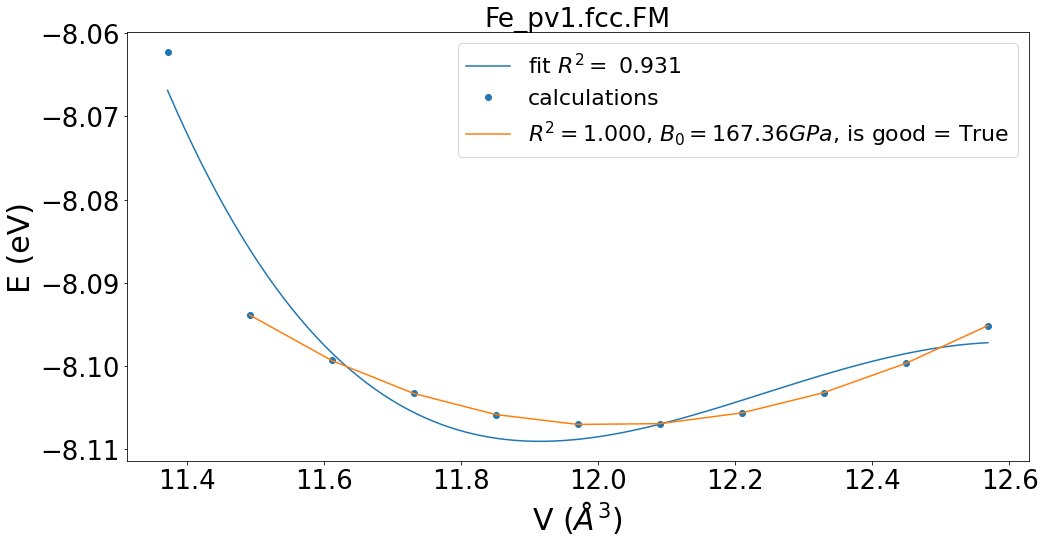

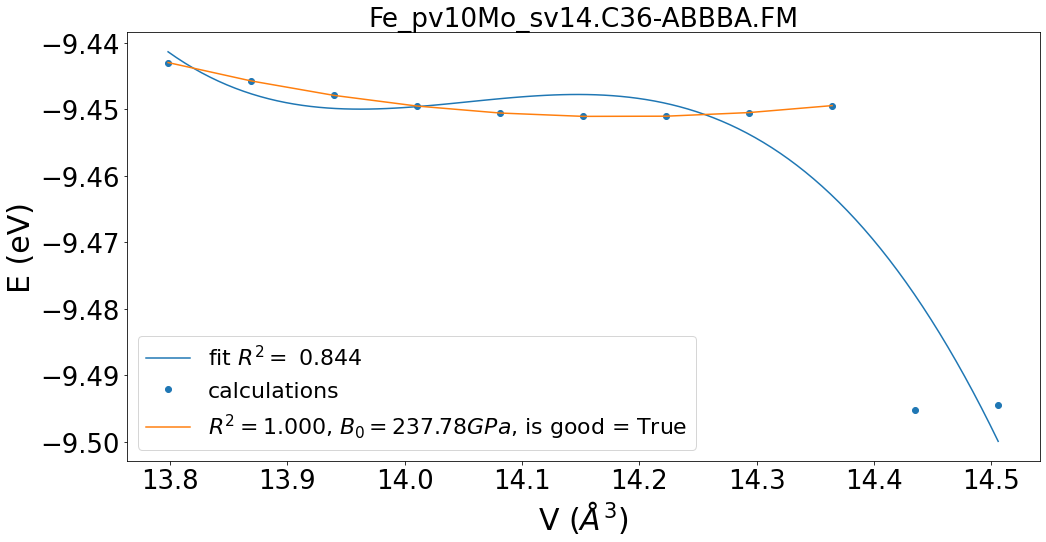

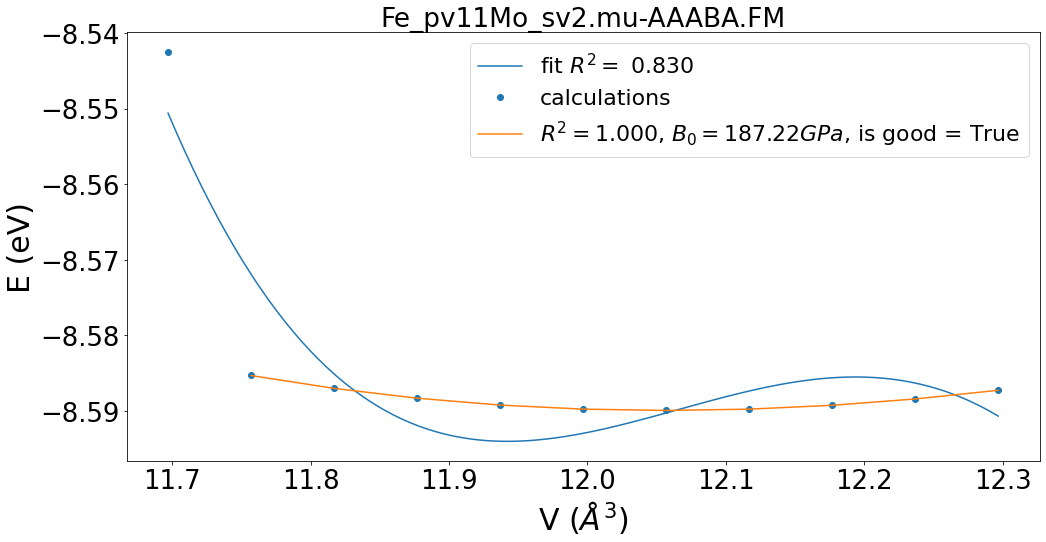

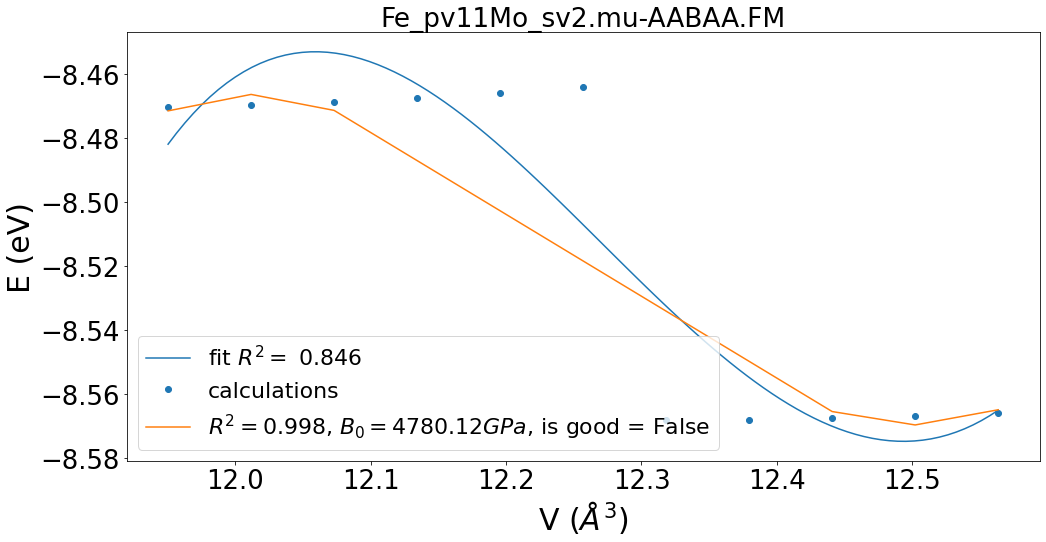

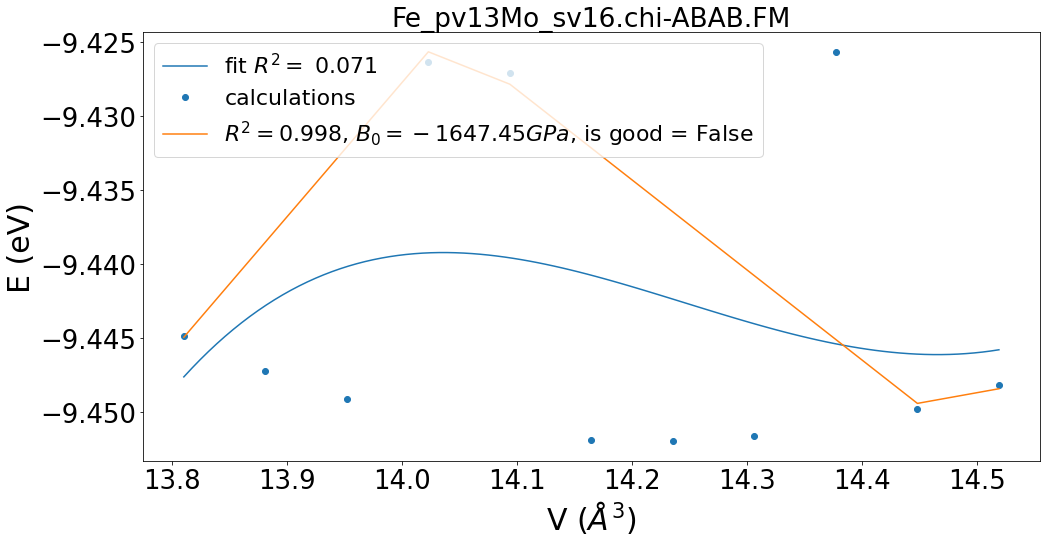

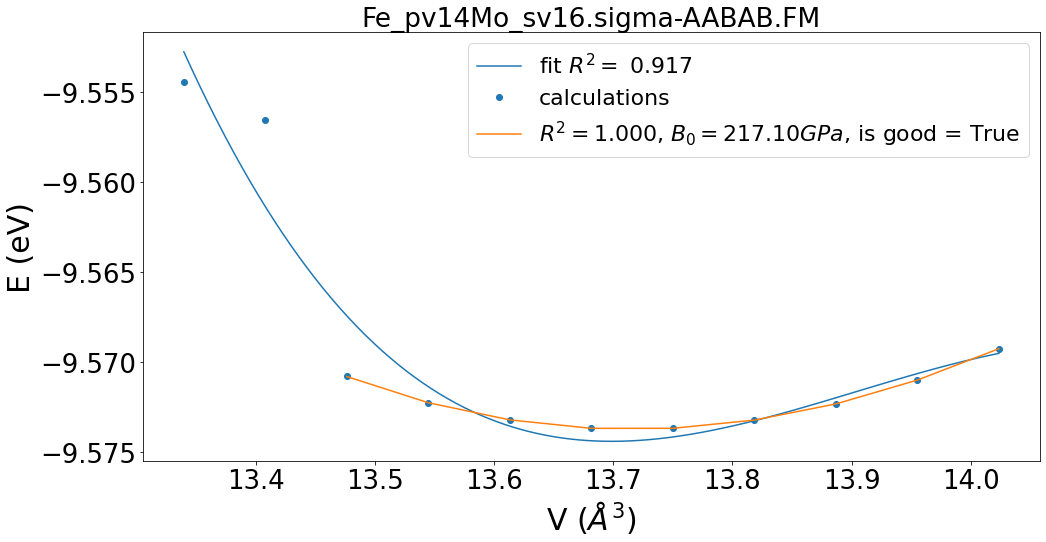

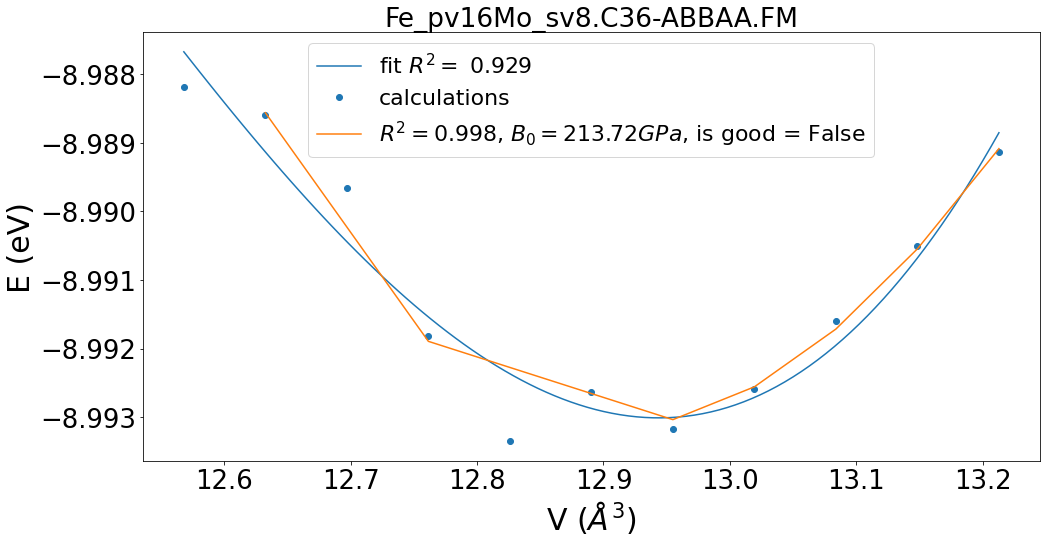

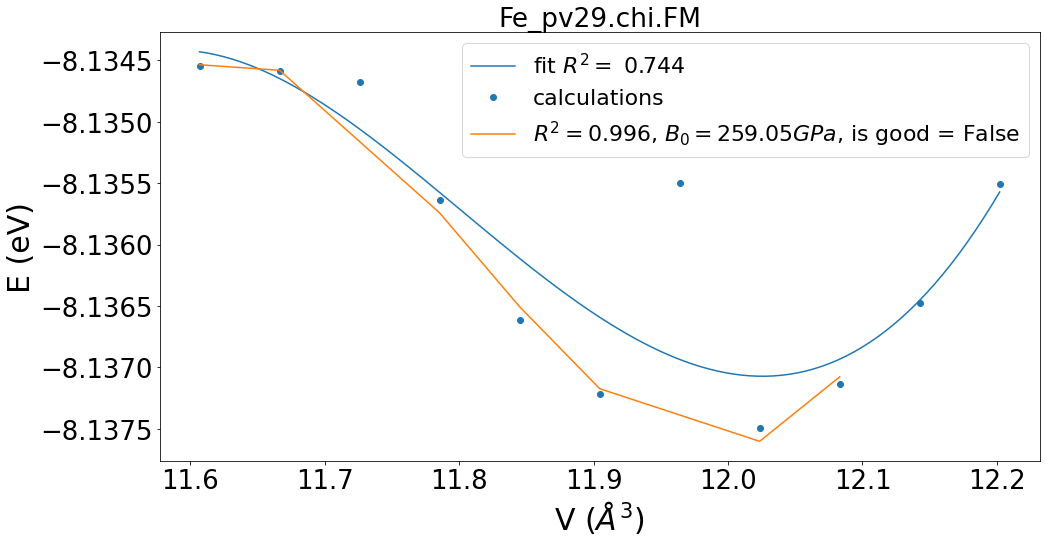

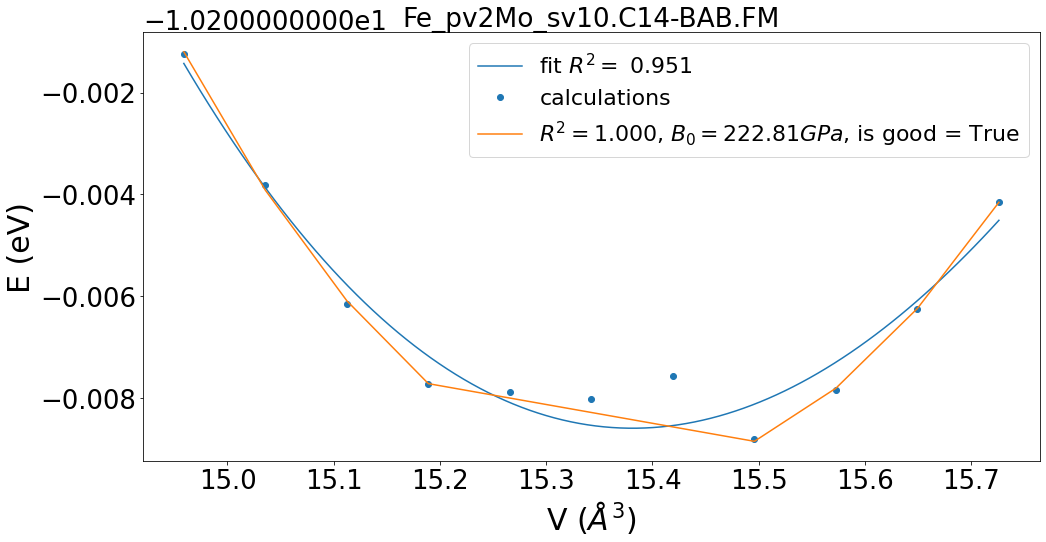

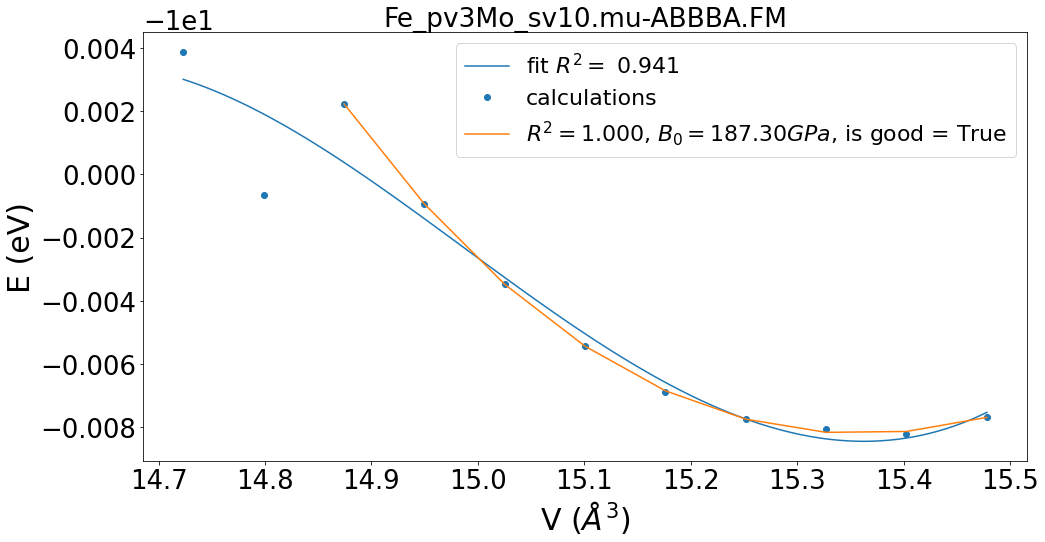

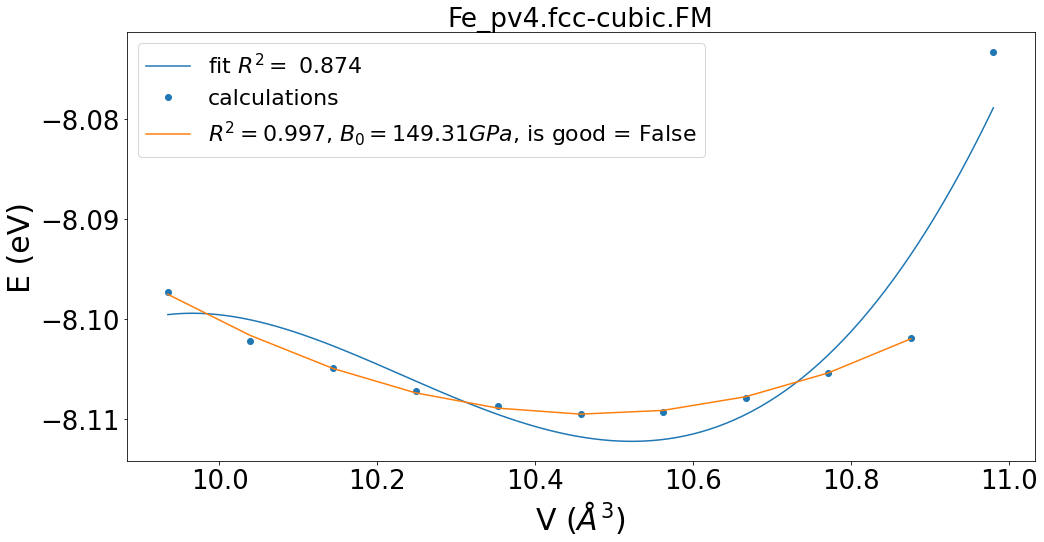

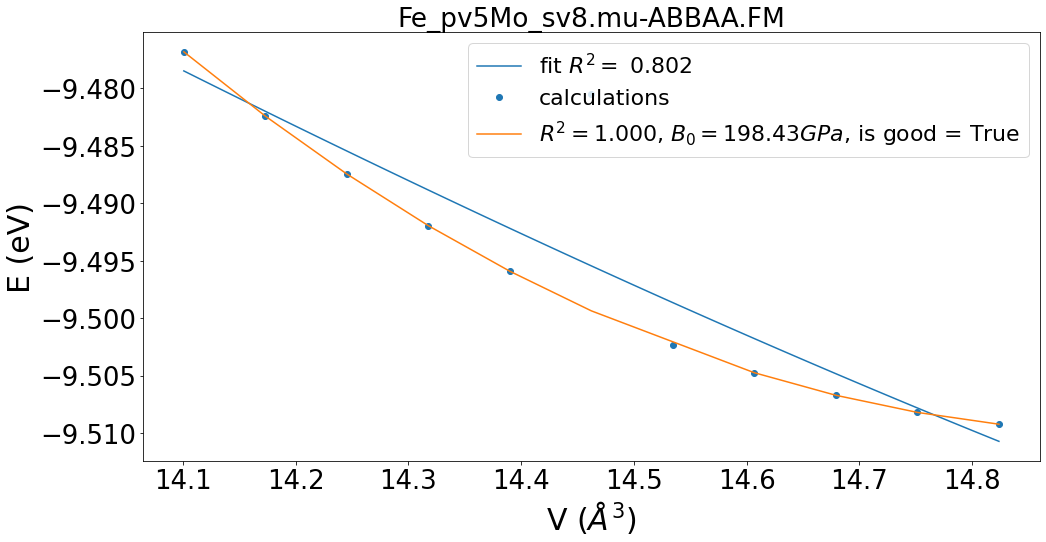

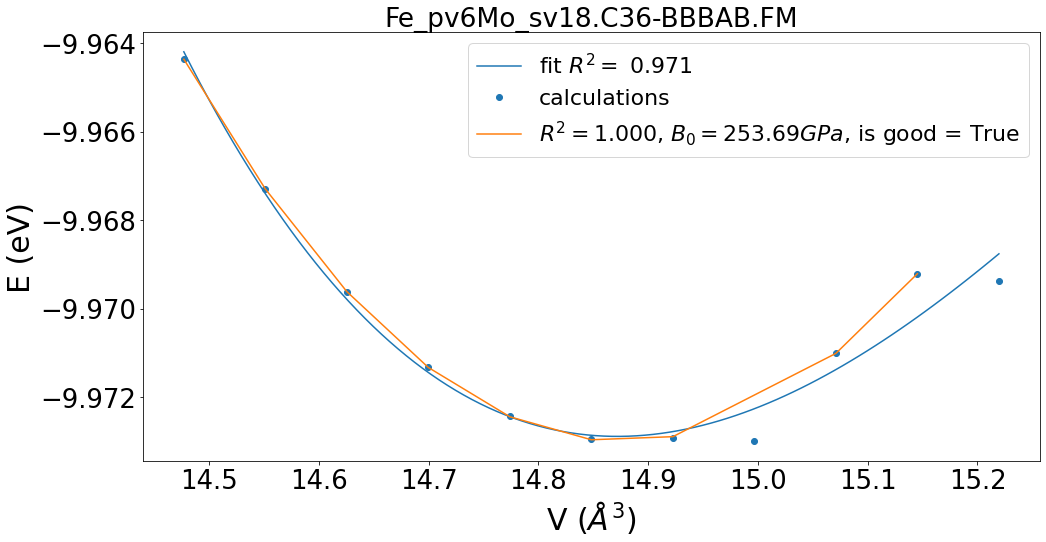

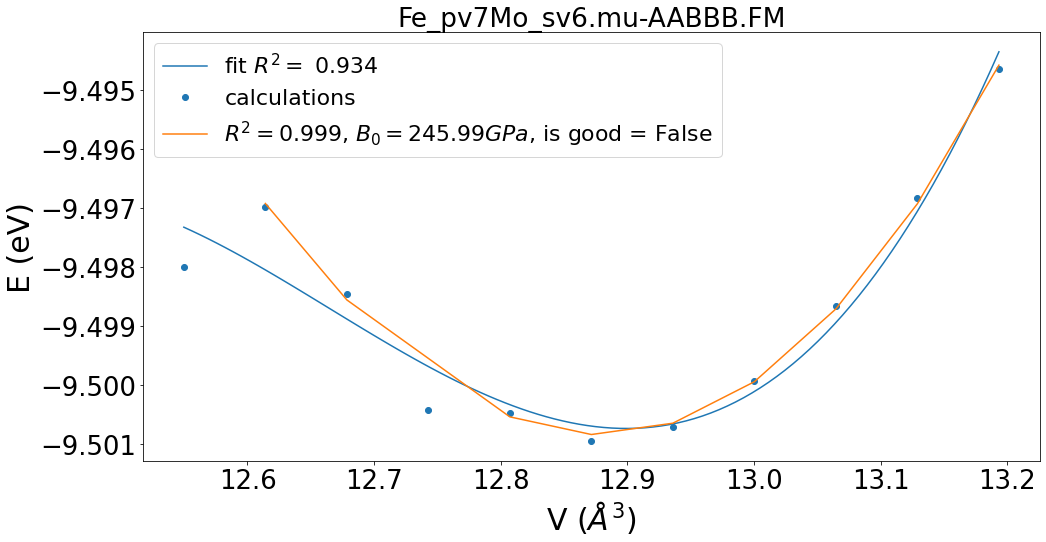

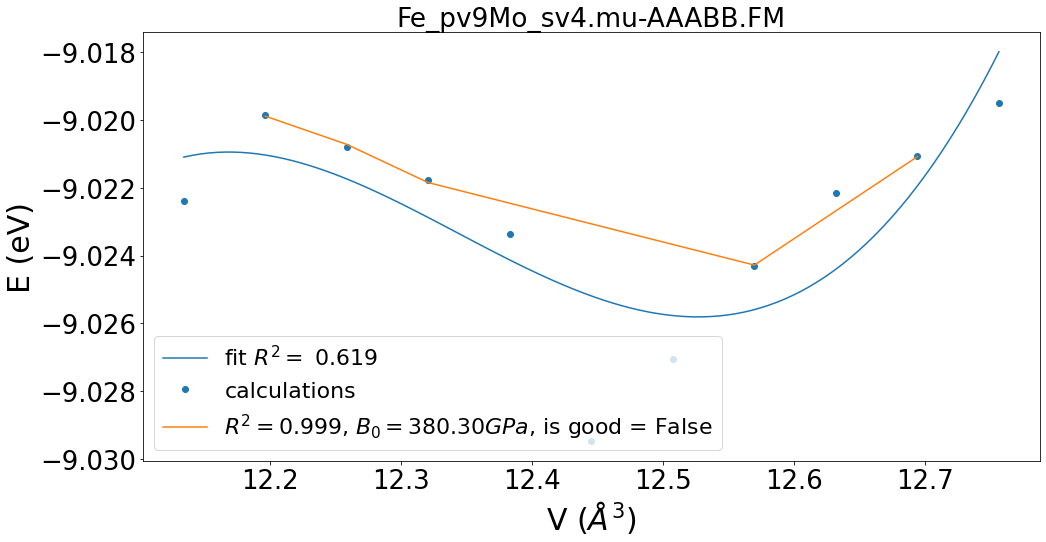

In [256]:
for index, fixedcurve in fixedevcurves.items():
    fig, ax = plot_curves(EVcurves[[index]], Fits[[index]], R2[[index]])
    #for i, (thisr2, thisv, thise, thisparams) in enumerate(zip(r2, reducedv, reducede, params_onreduced)):
    #    if i==0:
    for paramspec, curvedata in fixedcurve.items():
        x = curvedata['evcurve']['V']
        y = curvedata['evcurve']['E']
        currr2 = curvedata['r2']
        params = copy.copy(curvedata['fit'])
        currB0 = params[1]
        params[1] /= ev_per_angstrom3_to_GPA
        isgood = curvedata['IsGood']
        ax[0].plot(x, birchmurnaghan(x, *params), label=fr'$R^2 = {currr2:.3f}$, $B_0 = {currB0:.2f} GPa$, is good = {isgood}')
        ax[0].legend()

## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [45]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains(r'\..*[UD]+$') ]

## Obtain some info from indexes

In [46]:
Features = Featurizer(GoodBS)

In [47]:
GoodBS.shape

(279, 22)

# TODo this sould be in tools, as a phase cleaner

In [48]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [49]:
DescriptorsLoc = os.path.join(dataset,'Descriptors')
if not os.path.exists(DescriptorsLoc):
    os.makedirs(DescriptorsLoc)
Target_Class.to_pickle(os.path.join(DescriptorsLoc, 'ClassLabels.pkl'))

In [50]:
GoodBS['Phase'] = Target_Class

In [51]:
GoodBS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,-9.284767,1.845878,234.253474,13.459594,13.333333,10.215054,23.548387,0.504959,0.495041,0.251255,0.228968,0.204067
std,0.707220,0.361714,34.914824,1.572149,11.246102,9.598242,13.998085,0.292276,0.292276,0.163215,0.163491,0.167763
min,-10.932826,1.000000,91.497861,10.193118,1.000000,0.000000,1.000000,0.000000,0.000000,-0.015696,-0.042837,-0.085493
25%,-9.838152,2.000000,215.789849,12.203112,5.000000,2.500000,13.000000,0.266667,0.265409,0.124226,0.099778,0.071628
50%,-9.298898,2.000000,241.378288,13.235057,10.000000,8.000000,24.000000,0.500000,0.500000,0.227057,0.190274,0.168422
75%,-8.768073,2.000000,260.628327,14.716950,18.000000,16.000000,30.000000,0.734591,0.733333,0.360616,0.336242,0.308816
max,-7.780040,2.000000,287.396036,16.515851,56.000000,52.000000,56.000000,1.000000,1.000000,0.720407,0.720388,0.720388


# some E-V curves, good and bad

## sample bad

In [52]:
sample_bad_index = BadBS.sample(n=5).index#.append(pd.Index(['Mo_sv53.R.NM'])).unique()

In [53]:
sample_bad = EVcurves[sample_bad_index] #[BadBS.index].dropna().sample(n=min(5, BadBS.shape[0]))

In [54]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [55]:
sample_bad_r2 = R2[sample_bad.index]

In [56]:
sample_bad_fit = Fits[sample_bad.index]

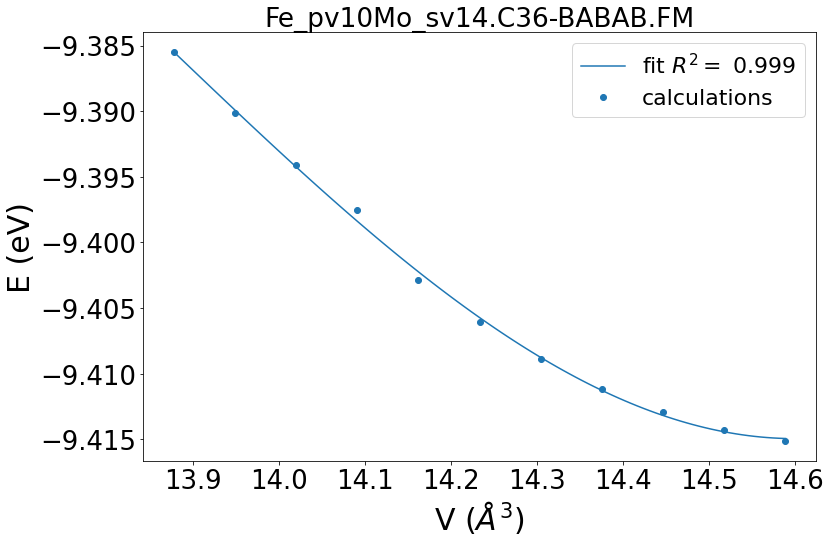

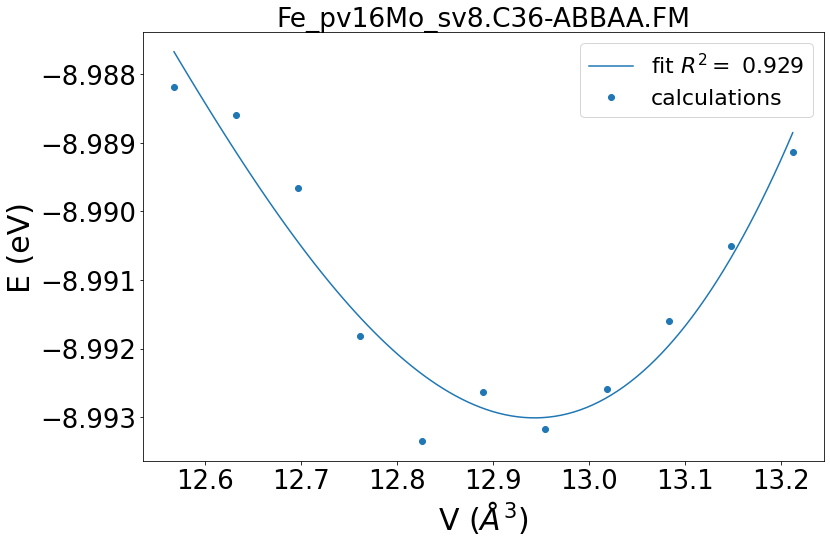

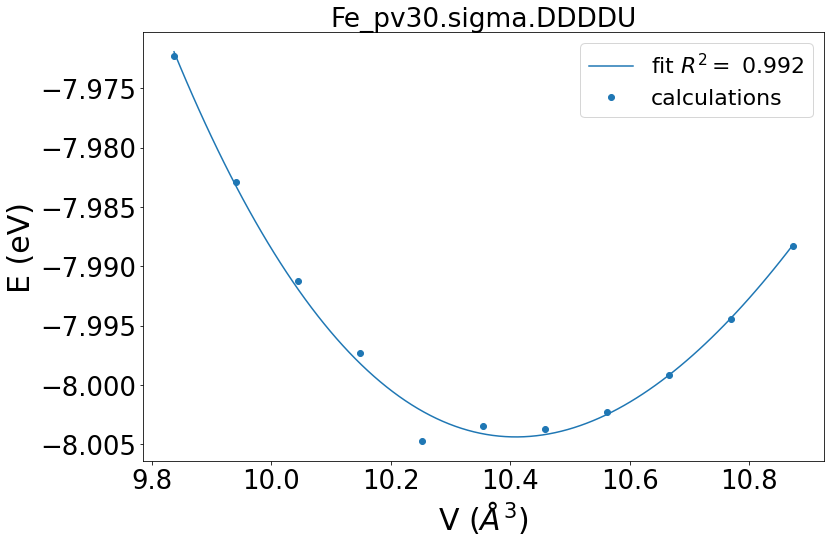

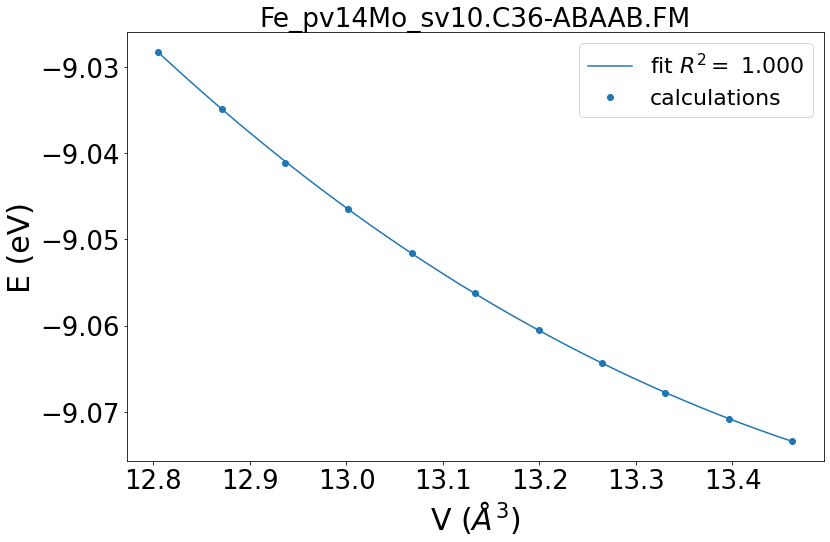

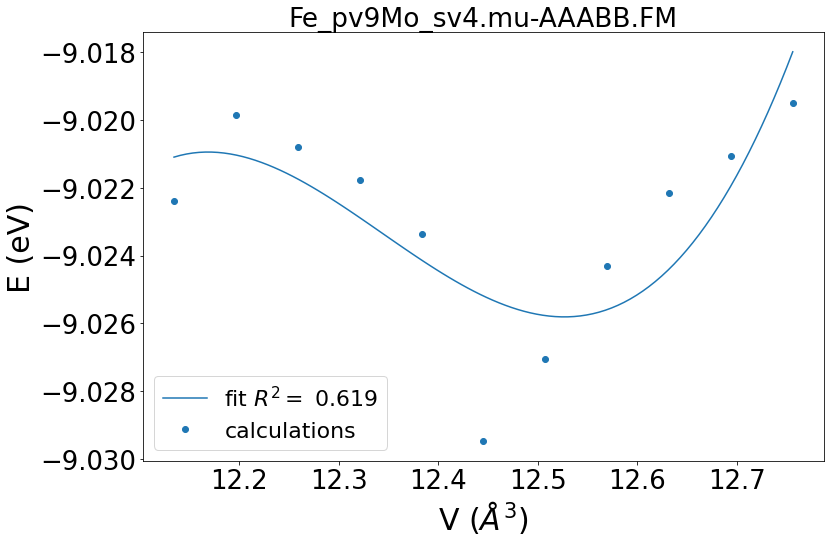

In [57]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

# Cases of interest

In [58]:
interesting_cases = ['Fe_pv28Mo_sv1.chi-BAAA.FM', 'Fe_pv11Mo_sv2.mu-AAABA.FM', 'Fe_pv1.fcc.FM', 'Fe_pv1.fcc.FM', Mo_R]

In [59]:
Better_evcurves_df.IsGood[interesting_cases]

Fe_pv28Mo_sv1.chi-BAAA.FM    False
Fe_pv11Mo_sv2.mu-AAABA.FM    False
Fe_pv1.fcc.FM                 True
Fe_pv1.fcc.FM                 True
Mo_sv53.R.NM                  True
Name: IsGood, dtype: bool

In [60]:
Fits.loc[interesting_cases][0]

{'xc=PBE-PAW.E=450.dk=0.020': array([-8.23994851e+00,  7.97575010e-01,  5.13504221e+03,  1.15394111e+01])}

In [61]:
Better_evcurves_df.ev_fit_results[interesting_cases][0]

{'E_murn': -8.240007,
 'V_murn': 11.555812,
 'B_murn': 20.484025,
 'Bdev_murn': 59.173261}

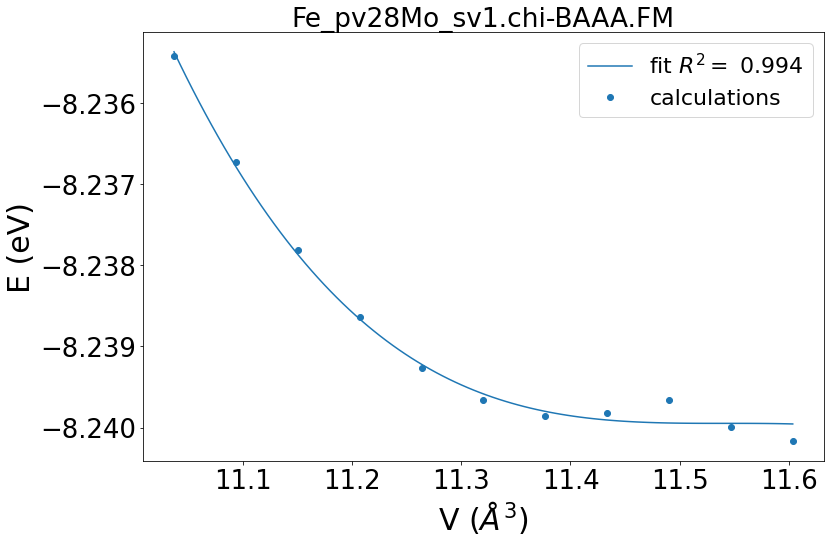

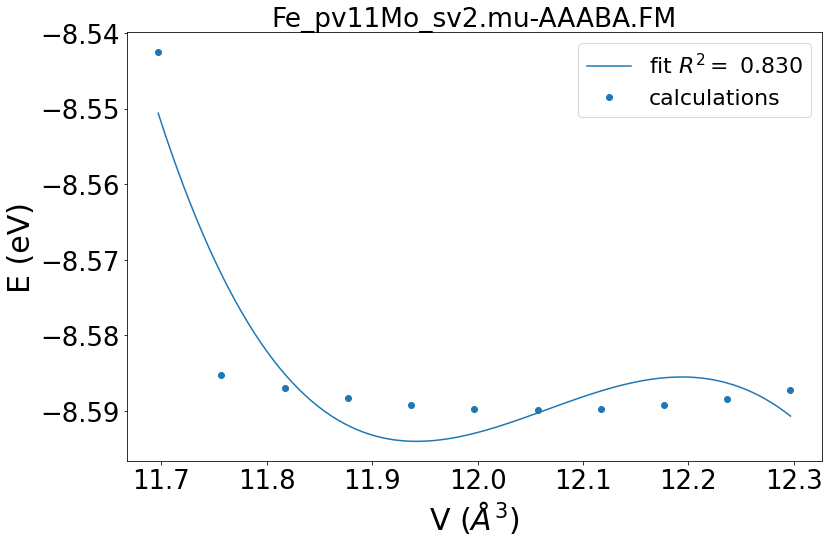

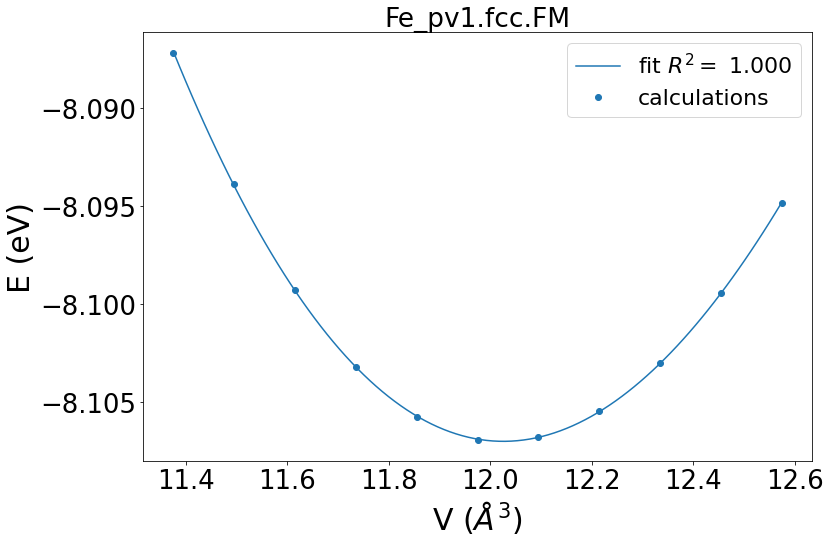

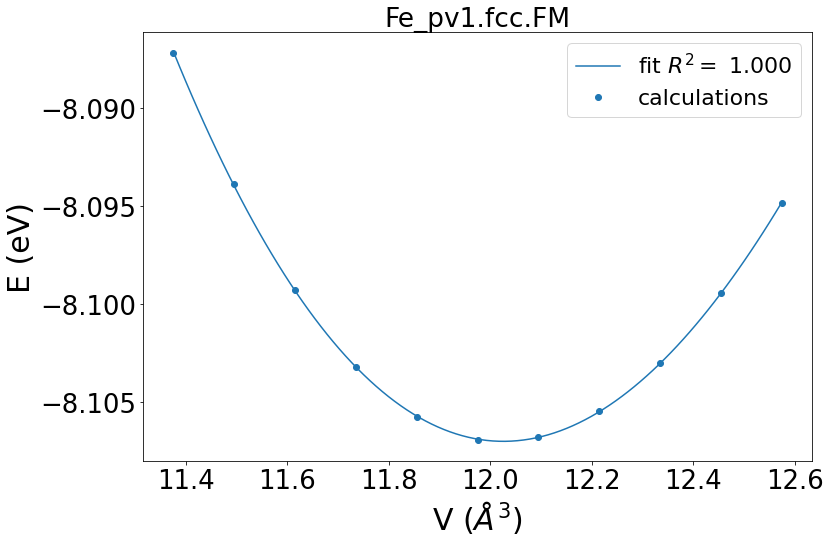

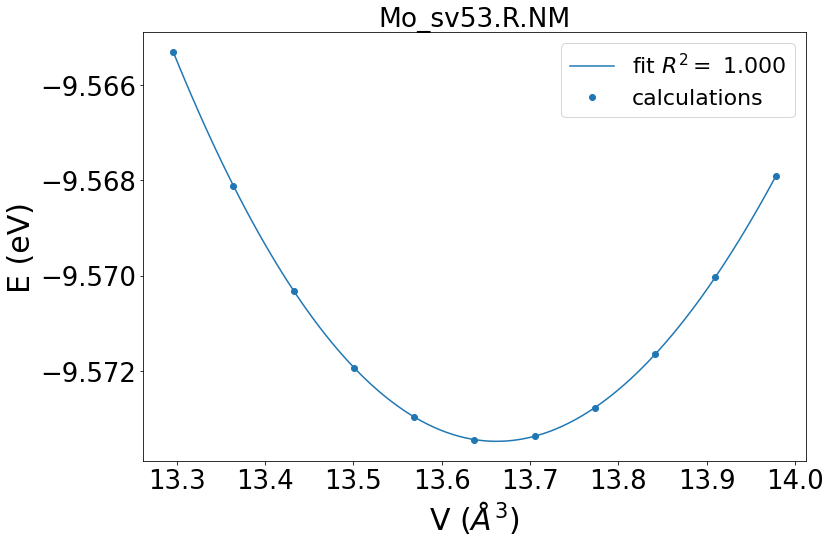

In [62]:
figs, axs = plot_curves(EVcurves[interesting_cases], Fits[interesting_cases], R2[interesting_cases])


# Sample good

In [63]:
GoodBS.shape

(279, 23)

In [64]:
sample_good = EVcurves[GoodBS.index].dropna().sample(n=5)

In [65]:
sample_good

Fe_pv18Mo_sv12.sigma-ABABA.FM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv29.chi.FM                    {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Fe_pv46Mo_sv7.R-BAAAAAABAAA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv18Mo_sv12.sigma-ABBAA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
dtype: object

In [66]:
sample_good_r2 = R2[sample_good.index]

In [67]:
sample_good_fit = Fits[sample_good.index]

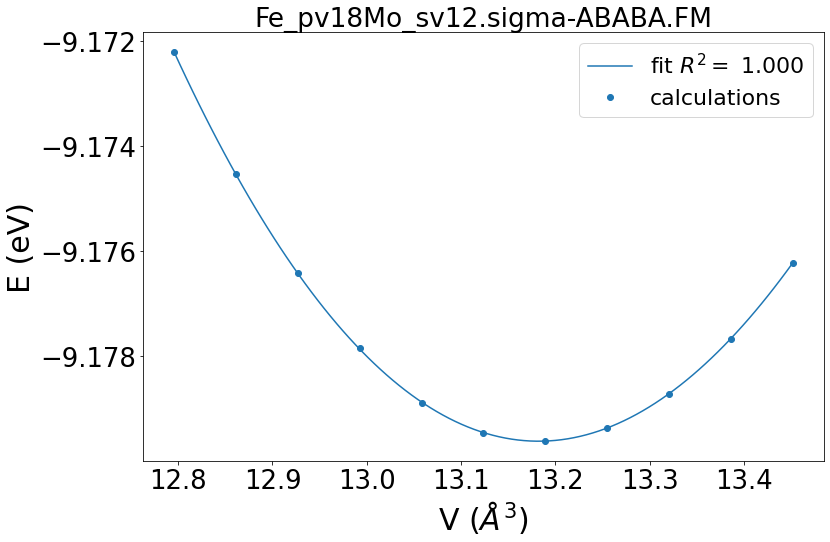

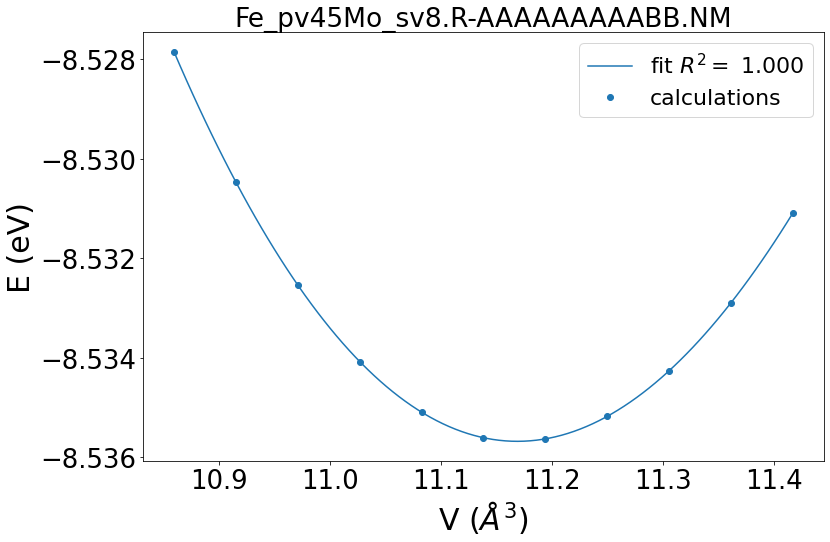

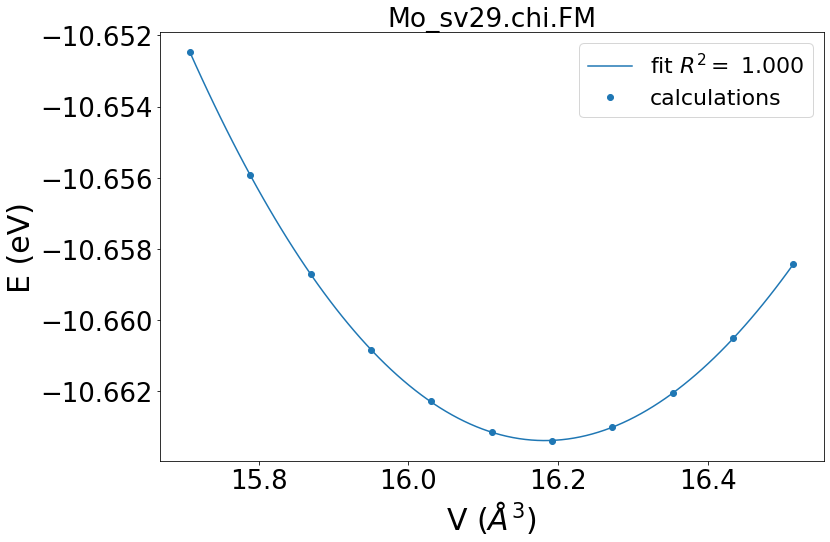

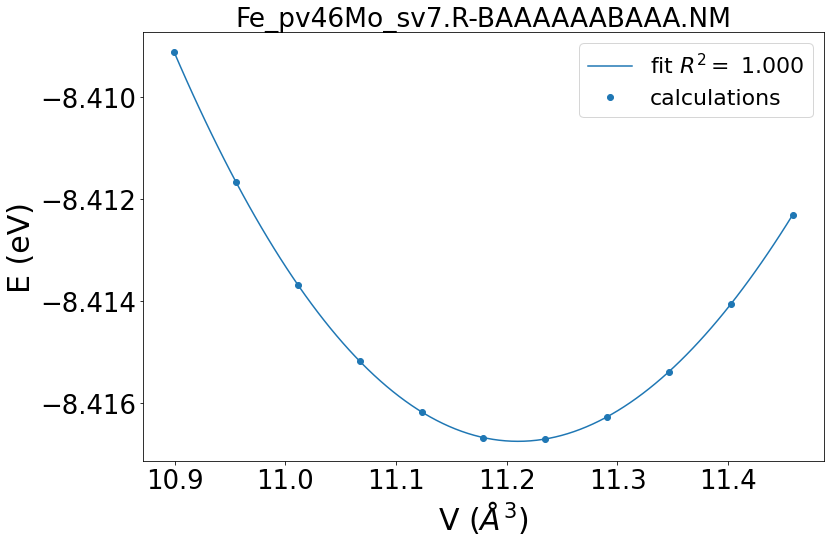

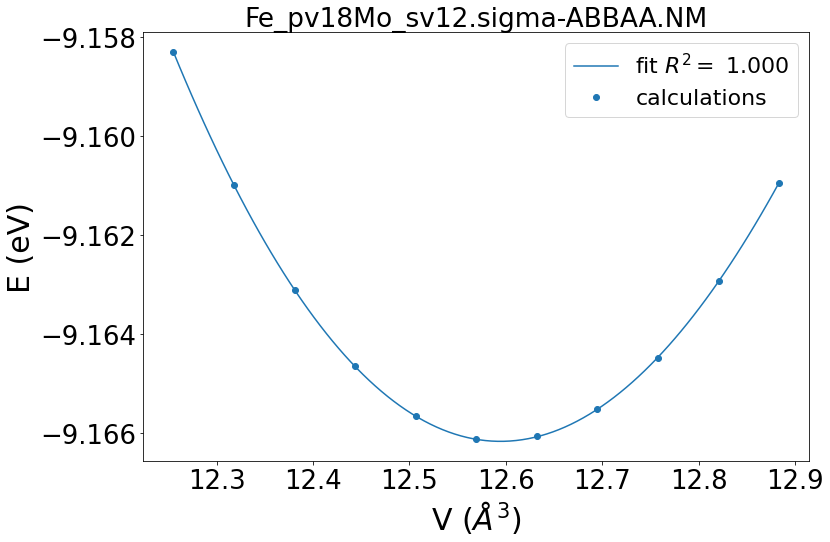

In [68]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

In [69]:
sample_max_B0 = GoodBS.query('nelem == 1').B0.idxmax()

In [70]:
sample_min_B0 = GoodBS.query('nelem == 1').B0.idxmin()

In [71]:
GoodBS.B0[[sample_min_B0]]

Fe_pv8.A15.FM    91.497861
Name: B0, dtype: float64

In [72]:
GoodBS.B0[[sample_max_B0]]

Fe_pv2.hcp.NM    287.396036
Name: B0, dtype: float64

In [73]:
theminbo = EVcurves_df.loc[sample_min_B0].dropna()

In [74]:
theminbo[0]

{'evcurve': {'V': array([11.77596875, 11.718525  , 11.66108125, 11.6036375 , 11.54619375,
         11.48875   , 11.43130625, 11.3738625 , 11.31641875, 11.258975  ,
         11.20153125]),
  'E': array([-8.16882538, -8.16924875, -8.16949388, -8.16966237, -8.16979713,
         -8.16965575, -8.169274  , -8.16873825, -8.16784763, -8.16654375,
         -8.16490275])},
 'ev_fit_results': {'E_murn': -8.169759,
  'V_murn': 11.558019,
  'B_murn': 91.497861,
  'Bdev_murn': 37.404391},
 'r2': 0.9996540118162385,
 'fit': array([-8.16976437, 96.30701986, 46.38697814, 11.5526264 ]),
 'IsGood': True,
 'calc_param': 'xc=PBE-PAW.E=450.dk=0.020'}

In [75]:
selection = ((GoodBS.B0>=GoodBS.B0[sample_min_B0]) & (GoodBS.B0<=GoodBS.B0[sample_max_B0]))

In [76]:
selection.sum()

279

In [77]:
selection_stricter = ((GoodBS.B0>1.1*GoodBS.B0[sample_min_B0]) & (GoodBS.B0<0.90*GoodBS.B0[sample_max_B0]) &
                     (list(R2[sample_max_B0].values())[0] > 0.998))

In [78]:
selection_stricter

Fe_pv8Mo_sv22.sigma-BBABB.FM       True
Fe_pv10Mo_sv20.sigma-ABBAB.FM      True
Fe_pv4Mo_sv20.C36-ABBBB.FM         True
Fe_pv5Mo_sv24.chi-AABB.FM          True
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    True
                                   ... 
Fe_pv16Mo_sv8.C36-ABBAA.NM         True
Fe_pv4Mo_sv2.C15-A2B.FM            True
Fe_pv8Mo_sv16.C36-BAABB.NM         True
Fe_pv4Mo_sv9.mu-BBBAA.FM           True
Fe_pv14Mo_sv16.sigma-AABBA.FM      True
Name: B0, Length: 279, dtype: bool

In [79]:
samples_wrong_b0 = GoodBS[~selection].index

In [80]:
len(samples_wrong_b0)

0

<AxesSubplot:ylabel='Frequency'>

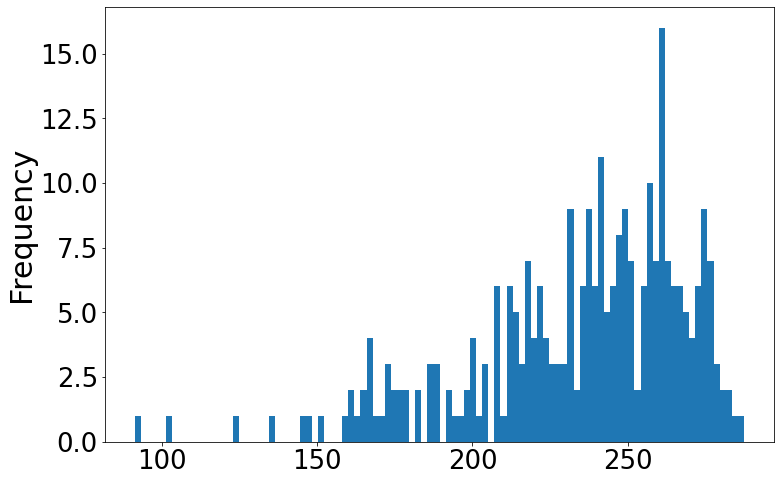

In [81]:
GoodBS.B0.plot.hist(bins=100)

In [82]:
curve_wrong_b0 = EVcurves[samples_wrong_b0]

In [83]:
r2_wrong_b0 = R2[samples_wrong_b0]

In [84]:
fits_wrong_b0 = Fits[samples_wrong_b0]

In [85]:
curve_wrong_b0

Series([], dtype: object)

In [86]:
figurecollection, axcollection  = plot_curves(curve_wrong_b0, fits_wrong_b0, r2_wrong_b0)
for ax, index  in zip(axcollection, samples_wrong_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

In [87]:
GoodBS.drop(index=samples_wrong_b0, inplace=True)

In [88]:
samples_low_b0 = GoodBS.query('B0 < 150').index

In [89]:
curve_low_b0 = EVcurves[samples_low_b0]

In [90]:
r2_low_b0 = R2[samples_low_b0]

In [91]:
fits_low_b0 = Fits[samples_low_b0]

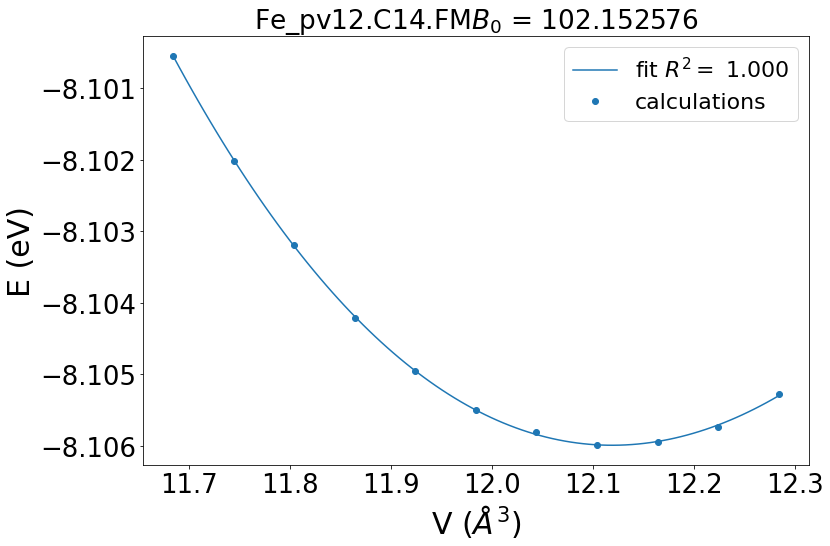

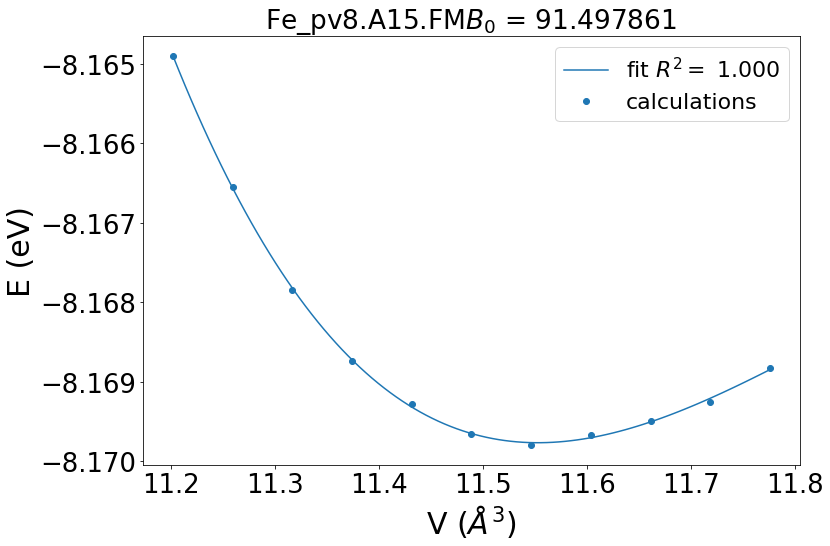

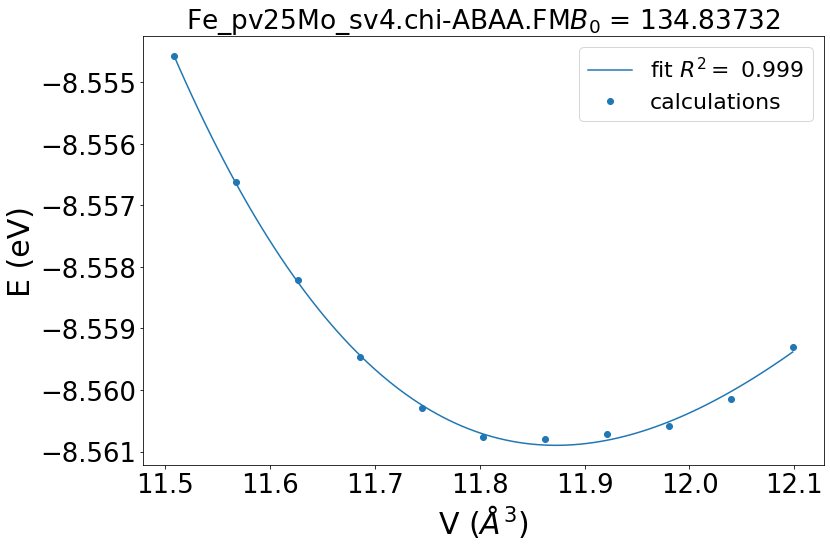

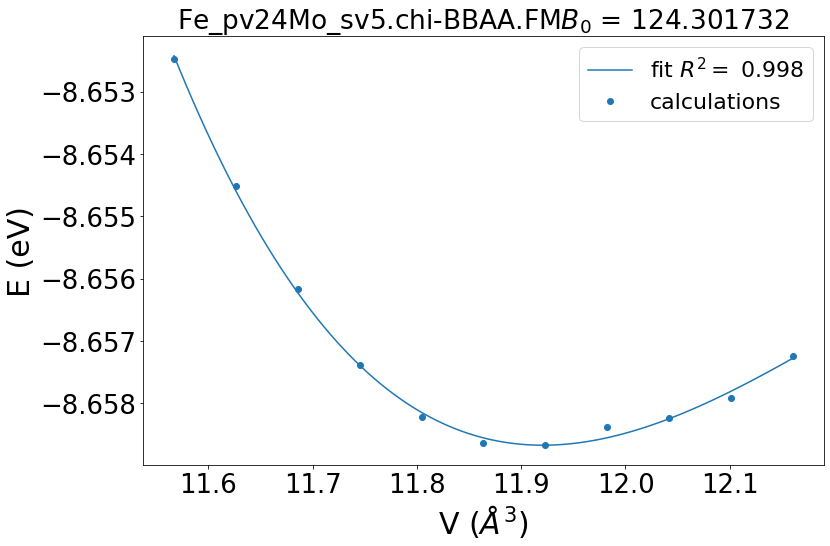

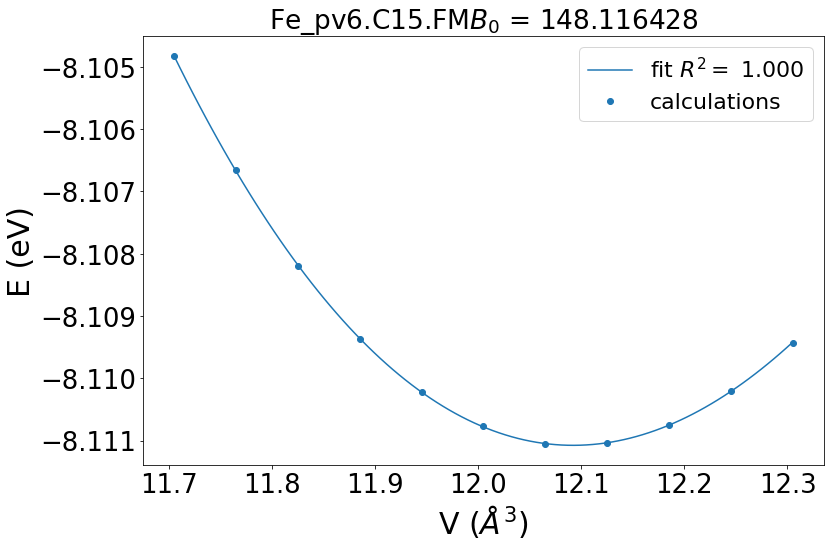

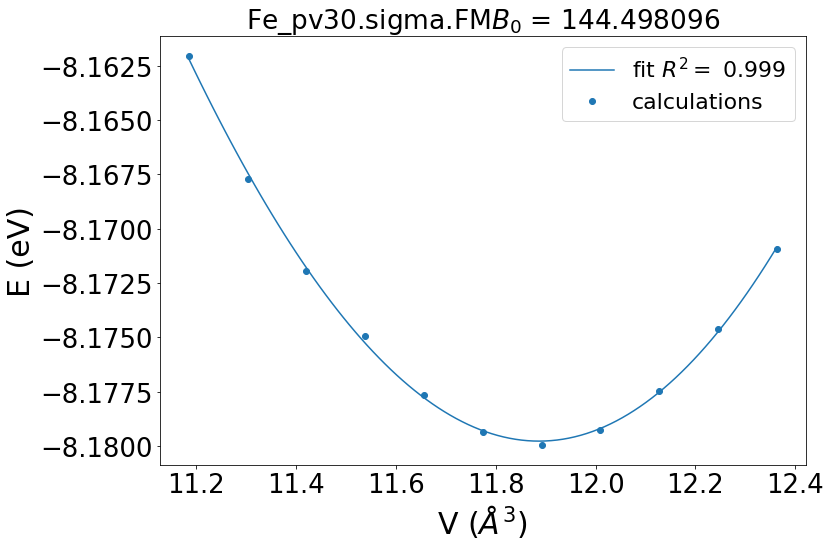

In [92]:
figurecollection, axcollection  = plot_curves(curve_low_b0, fits_low_b0, r2_low_b0)
for ax, index  in zip(axcollection, samples_low_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

# Save for later use 

In [93]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
GoodBS.to_pickle(curatedbs)

<AxesSubplot:>

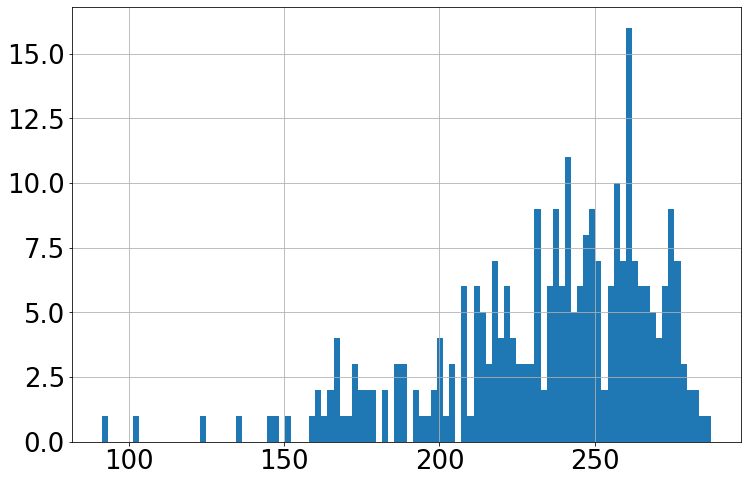

In [94]:
GoodBS.B0.hist(bins=100)

In [95]:
good_R_Mo = GoodBS.query('Phase == "R" and nelem == 1 and Mo_sv == 1').index

([<Figure size 864x576 with 1 Axes>, <Figure size 864x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Mo_sv53.R.NM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>,
  <AxesSubplot:title={'center':'Mo_sv53.R-Mo.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

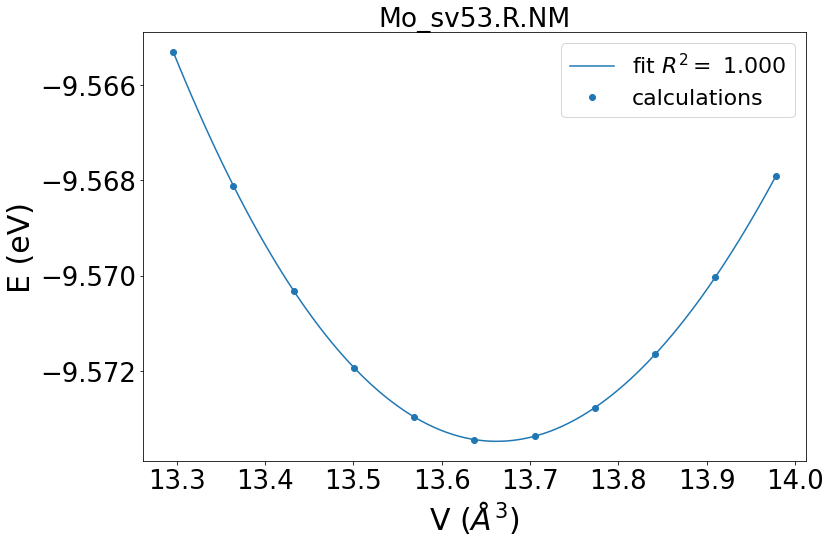

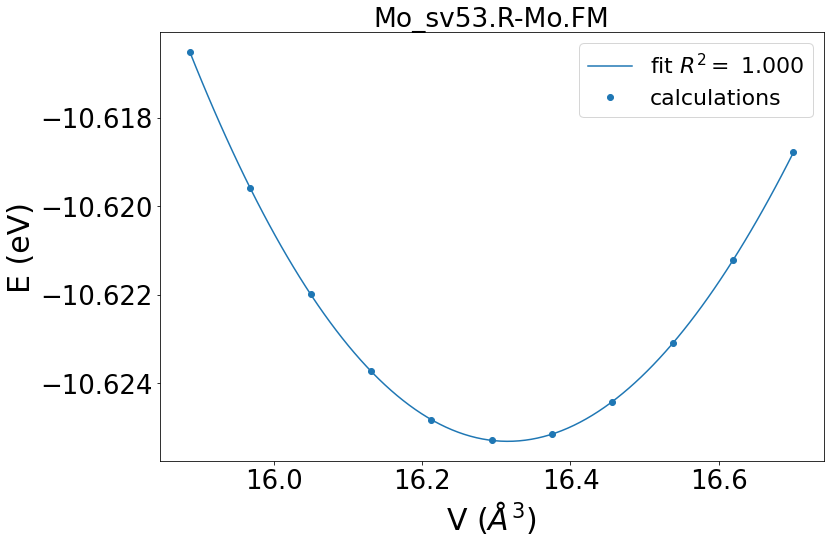

In [96]:
plot_curves(EVcurves[good_R_Mo], Fits[good_R_Mo], R2[good_R_Mo])

Surprise ! FM R Mo showed up ! Is this The only FM R ?

In [97]:
GoodBS.query('Phase == "R" and index.str.contains("FM")')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Mo_sv53.R-Mo.FM,bulk R-Mo.FM,16.315255 A,-10.625316,238.811481 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,0.0,1.0,0.307475,0.307475,0.307475,R


no, so I will remove it just for consistency (and this is the only FM R!

In [98]:
remove = GoodBS.query('Phase == "R" and index.str.contains("FM")').index

In [99]:
remove

Index(['Mo_sv53.R-Mo.FM'], dtype='object')

In [100]:
GoodBS.drop(index=remove, inplace=True)

In [101]:
GoodBS.to_pickle(curatedbs)